# 📊 Análisis Exploratorio de Datos (EDA) - Proyecto Orion

## Objetivo
Explorar los datos generados por el sistema Orion para entender:
- Distribución de clientes por tipo, sector y zona de riesgo
- Patrones de consumo eléctrico
- Distribución de prioridades
- Evolución temporal del sistema

**Zona horaria:** Perú (UTC-5)

In [ ]:
# ============================================================
# IMPORTS Y CONFIGURACIÓN
# ============================================================

import sys
from pathlib import Path

# Agregar src al path
sys.path.append(str(Path.cwd().parent))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.utilidades.tiempo import ahora_peru
from src.utilidades.registrador import registro

# Configuración de gráficos
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

print(f"📅 Hora Perú: {ahora_peru().strftime('%Y-%m-%d %H:%M:%S')}")
print("✅ Librerías cargadas correctamente")

## 1. Carga de Datos

Cargamos los datos desde las carpetas oficiales del proyecto.

In [2]:
# ============================================================
# CARGAR DATOS
# ============================================================

# Rutas de datos
paths = {
    'clientes': Path('../datos/brutos/clientes'),
    'consumo': Path('../datos/brutos/consumo'),
    'alarmas': Path('../datos/brutos/alarmas'),
    'facturacion': Path('../datos/brutos/facturacion'),
    'inspecciones': Path('../datos/brutos/inspecciones'),
    'historico': Path('../datos/procesados/historico_puntajes.parquet'),
    'puntajes': Path('../datos/procesados/puntajes_latest.parquet')
}

# Función para cargar parquets
def cargar_datos(ruta):
    if ruta.exists():
        if ruta.is_dir():
            archivos = list(ruta.glob('*.parquet'))
            if archivos:
                return pd.concat([pd.read_parquet(f) for f in archivos], ignore_index=True)
        else:
            return pd.read_parquet(ruta)
    return None

# Cargar todos los datos
datos = {}
for nombre, ruta in paths.items():
    df = cargar_datos(ruta)
    if df is not None:
        datos[nombre] = df
        print(f"✅ {nombre}: {len(df)} registros, {len(df.columns)} columnas")
    else:
        print(f"⚠️ {nombre}: No disponible")

print(f"\n📊 Datos cargados: {len(datos)} datasets")

✅ clientes: 202 registros, 9 columnas
✅ consumo: 148196 registros, 4 columnas
✅ alarmas: 210 registros, 4 columnas
✅ facturacion: 2424 registros, 7 columnas
✅ inspecciones: 159 registros, 8 columnas
✅ historico: 362 registros, 9 columnas
✅ puntajes: 362 registros, 6 columnas

📊 Datos cargados: 7 datasets


## 2. Análisis de Clientes

Exploramos la distribución de clientes por tipo, sector y zona de riesgo.

In [3]:
# ============================================================
# ANÁLISIS DE CLIENTES
# ============================================================

if 'clientes' in datos:
    df_clientes = datos['clientes']
    
    print("=" * 60)
    print("📋 ANÁLISIS DE CLIENTES")
    print("=" * 60)
    
    # Información general
    print(f"\n📊 Total clientes: {len(df_clientes)}")
    print(f"📊 Columnas: {df_clientes.columns.tolist()}")
    
    # Distribución por tipo de cliente
    if 'tipo_cliente' in df_clientes.columns:
        print("\n📊 Distribución por tipo de cliente:")
        print(df_clientes['tipo_cliente'].value_counts())
    
    # Distribución por sector
    if 'sector' in df_clientes.columns:
        print("\n📊 Distribución por sector:")
        print(df_clientes['sector'].value_counts())
    
    # Mostrar primeras filas
    print("\n📋 Primeras 5 filas:")
    display(df_clientes.head())
else:
    print("⚠️ No hay datos de clientes")

📋 ANÁLISIS DE CLIENTES

📊 Total clientes: 202
📊 Columnas: ['id_cliente', 'nombre', 'tipo_cliente', 'potencia_contratada', 'sector', 'zona_riesgo', 'tarifa', 'fecha', 'estado_pago']

📊 Distribución por tipo de cliente:
tipo_cliente
Residencial    119
Comercial       46
Industrial      13
Restaurante      7
Fabrica          6
Résídéncíál      3
Cómércíál        2
Indústríál       1
Name: count, dtype: int64

📊 Distribución por sector:
sector
Independencia             19
Piura                     16
Comas                     12
Tumbes                    12
Huánuco                   11
Alto Trujillo             11
Callao                    11
San Juan De Lurigancho    11
Los Olivos                10
Villa El Salvador         10
Huaral                     9
Ate                        9
La Esperanza               8
Máncora                    8
La  Esperanza              5
Huanuco                    5
Sjl                        5
Losolivos                  5
Laesperanza                4
Altot

,id_cliente,nombre,tipo_cliente,potencia_contratada,sector,zona_riesgo,tarifa,fecha,estado_pago
0,CL-00001,Cliente 1,Residencial,9.7,Comas,False,Mt3,2020-01-27,Suspendido
1,CL-00002,Cliente 2,Residencial,4.4,Tumbes,False,Bt4,2022-10-21,Suspendido
2,00003,Cliente 3,None,8.3,Alto Trujillo,True,Bt5B,2020-10-30,Suspendido
3,CL_00004,None,Comercial,27.9,La Esperanza,True,Bt5A,2020-04-24,Activo
4,cl-00005,Cliente 5,Residencial,4.3,Losolivos,False,Bt5A,2020-11-18,Activo


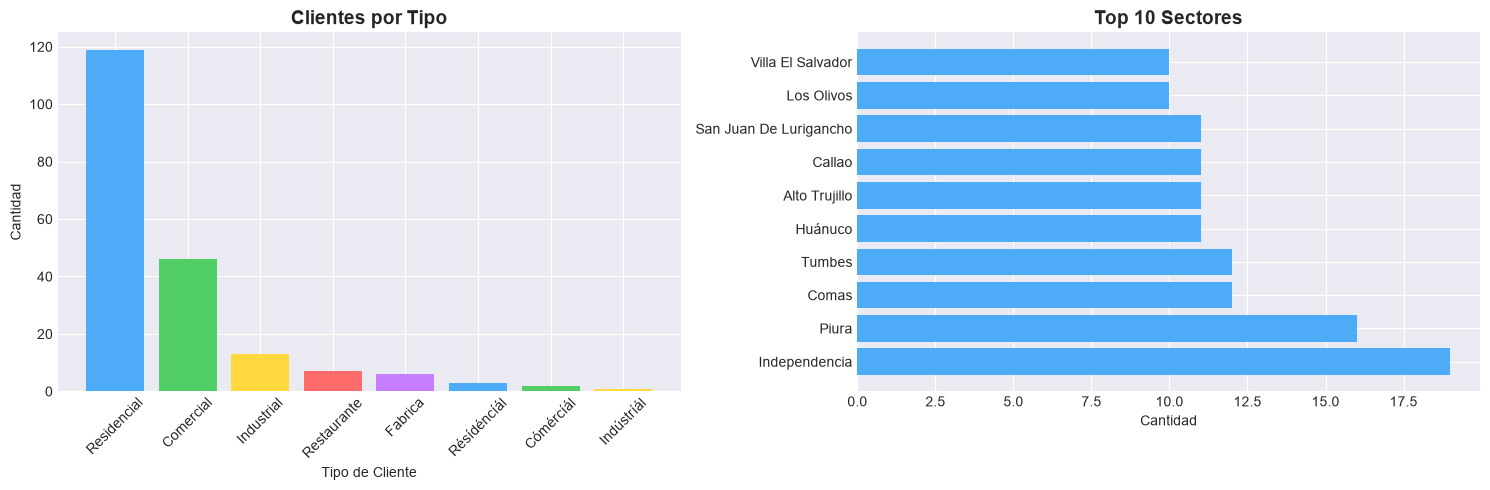

In [4]:
# ============================================================
# VISUALIZACIÓN DE CLIENTES
# ============================================================

if 'clientes' in datos:
    df_clientes = datos['clientes']
    
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    # Gráfico 1: Distribución por tipo
    if 'tipo_cliente' in df_clientes.columns:
        tipo_counts = df_clientes['tipo_cliente'].value_counts()
        axes[0].bar(tipo_counts.index, tipo_counts.values, 
                    color=['#4dabf7', '#51cf66', '#ffd93d', '#ff6b6b', '#c77dff'])
        axes[0].set_title('Clientes por Tipo', fontsize=14, fontweight='bold')
        axes[0].set_xlabel('Tipo de Cliente')
        axes[0].set_ylabel('Cantidad')
        axes[0].tick_params(axis='x', rotation=45)
    
    # Gráfico 2: Distribución por sector
    if 'sector' in df_clientes.columns:
        sector_counts = df_clientes['sector'].value_counts().head(10)
        axes[1].barh(sector_counts.index, sector_counts.values, color='#4dabf7')
        axes[1].set_title('Top 10 Sectores', fontsize=14, fontweight='bold')
        axes[1].set_xlabel('Cantidad')
    
    plt.tight_layout()
    plt.show()

## 3. Análisis de Consumo

Exploramos los patrones de consumo eléctrico.

⚡ ANÁLISIS DE CONSUMO

📊 Total registros: 148196
📊 Clientes únicos: 362

📊 Estadísticas de consumo:
count    141531.000000
mean        -21.007051
std         923.688324
min      -66813.931975
25%          10.330000
50%          18.920000
75%          41.555000
max         722.140000
Name: consumo_kwh, dtype: float64


C:\Users\angel\AppData\Local\Temp\ipykernel_17548\3577633906.py:30: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1].boxplot(df_consumo['consumo_kwh'].dropna(), vert=True)


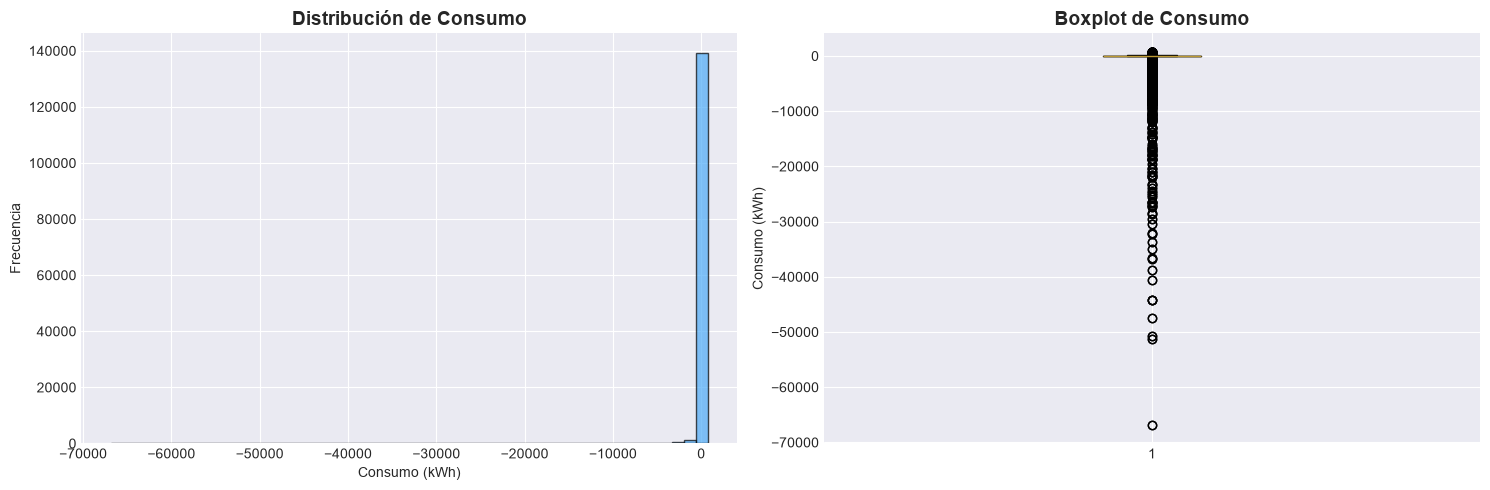

In [5]:
# ============================================================
# ANÁLISIS DE CONSUMO
# ============================================================

if 'consumo' in datos:
    df_consumo = datos['consumo']
    
    print("=" * 60)
    print("⚡ ANÁLISIS DE CONSUMO")
    print("=" * 60)
    
    print(f"\n📊 Total registros: {len(df_consumo)}")
    print(f"📊 Clientes únicos: {df_consumo['id_cliente'].nunique()}")
    
    if 'consumo_kwh' in df_consumo.columns:
        print(f"\n📊 Estadísticas de consumo:")
        print(df_consumo['consumo_kwh'].describe())
        
        # Visualización
        fig, axes = plt.subplots(1, 2, figsize=(15, 5))
        
        # Histograma
        axes[0].hist(df_consumo['consumo_kwh'].dropna(), bins=50, 
                     color='#4dabf7', edgecolor='black', alpha=0.7)
        axes[0].set_title('Distribución de Consumo', fontsize=14, fontweight='bold')
        axes[0].set_xlabel('Consumo (kWh)')
        axes[0].set_ylabel('Frecuencia')
        
        # Boxplot
        axes[1].boxplot(df_consumo['consumo_kwh'].dropna(), vert=True)
        axes[1].set_title('Boxplot de Consumo', fontsize=14, fontweight='bold')
        axes[1].set_ylabel('Consumo (kWh)')
        
        plt.tight_layout()
        plt.show()
else:
    print("⚠️ No hay datos de consumo")

## 4. Análisis del Histórico de Puntajes

Exploramos la evolución del sistema a lo largo del tiempo.

In [6]:
# ============================================================
# ANÁLISIS DEL HISTÓRICO
# ============================================================

if 'historico' in datos:
    df_historico = datos['historico']
    
    print("=" * 60)
    print("📊 ANÁLISIS DEL HISTÓRICO")
    print("=" * 60)
    
    print(f"\n📊 Total registros: {len(df_historico)}")
    print(f"📊 Columnas: {df_historico.columns.tolist()}")
    
    if 'ejecucion_id' in df_historico.columns:
        print(f"\n📊 Total ejecuciones: {df_historico['ejecucion_id'].nunique()}")
        print(f"📊 Clientes únicos: {df_historico['id_cliente'].nunique()}")
    
    if 'prioridad' in df_historico.columns:
        print(f"\n📊 Distribución de prioridades:")
        print(df_historico['prioridad'].value_counts())
    
    # Mostrar primeras filas
    print("\n📋 Primeras 5 filas:")
    display(df_historico.head())
else:
    print("⚠️ No hay histórico disponible")
    print("💡 Ejecuta: python scripts/ejecutar_flujo_completo.py")

📊 ANÁLISIS DEL HISTÓRICO

📊 Total registros: 362
📊 Columnas: ['id_cliente', 'probabilidad', 'impacto_economico', 'historial', 'puntaje_prioridad', 'prioridad', 'fecha_ejecucion', 'ejecucion_id', 'tipo_dato']

📊 Total ejecuciones: 1
📊 Clientes únicos: 362

📊 Distribución de prioridades:
prioridad
BAJA     121
ALTA     121
MEDIA    120
Name: count, dtype: int64

📋 Primeras 5 filas:


,id_cliente,probabilidad,impacto_economico,historial,puntaje_prioridad,prioridad,fecha_ejecucion,ejecucion_id,tipo_dato
0,cl-00170,0.973011,1.0,0.150,0.898806,ALTA,2026-09-10 20:32:02.652955-05:00,20260910_203202,puntaje
1,cl00072,0.990054,1.0,0.000,0.894032,ALTA,2026-09-10 20:32:02.652955-05:00,20260910_203202,puntaje
2,CL- 00182,0.986887,1.0,0.000,0.892132,ALTA,2026-09-10 20:32:02.652955-05:00,20260910_203202,puntaje
3,CL_00074,0.985650,1.0,0.000,0.891390,ALTA,2026-09-10 20:32:02.652955-05:00,20260910_203202,puntaje
4,00076,0.969910,1.0,0.075,0.889446,ALTA,2026-09-10 20:32:02.652955-05:00,20260910_203202,puntaje


C:\Users\angel\AppData\Local\Temp\ipykernel_17548\4286568109.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  evolucion = df_historico.groupby(['fecha_ejecucion', 'prioridad']).size().reset_index(name='count')


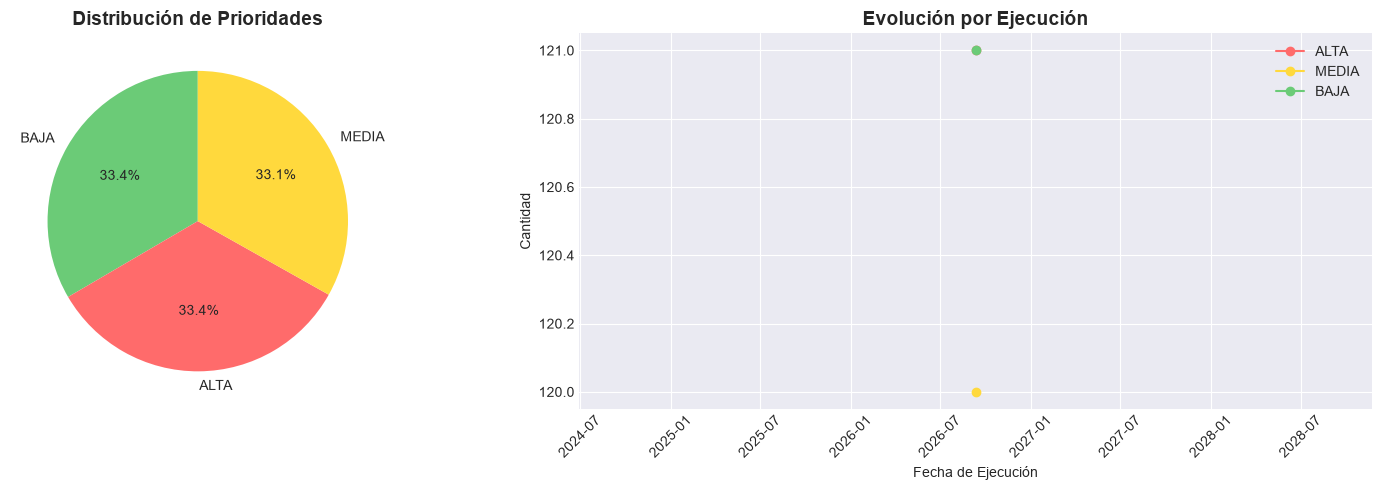

In [7]:
# ============================================================
# VISUALIZACIÓN DEL HISTÓRICO
# ============================================================

if 'historico' in datos:
    df_historico = datos['historico']
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    
    # Gráfico 1: Distribución de prioridades
    if 'prioridad' in df_historico.columns:
        prioridad_counts = df_historico['prioridad'].value_counts()
        colores = {'ALTA': '#ff6b6b', 'MEDIA': '#ffd93d', 'BAJA': '#6bcb77'}
        colors_list = [colores.get(p, '#4dabf7') for p in prioridad_counts.index]
        
        axes[0].pie(prioridad_counts.values, labels=prioridad_counts.index, 
                    autopct='%1.1f%%', colors=colors_list, startangle=90)
        axes[0].set_title('Distribución de Prioridades', fontsize=14, fontweight='bold')
    
    # Gráfico 2: Evolución por ejecución
    if 'fecha_ejecucion' in df_historico.columns and 'prioridad' in df_historico.columns:
        evolucion = df_historico.groupby(['fecha_ejecucion', 'prioridad']).size().reset_index(name='count')
        
        for prioridad in ['ALTA', 'MEDIA', 'BAJA']:
            data = evolucion[evolucion['prioridad'] == prioridad]
            if not data.empty:
                axes[1].plot(data['fecha_ejecucion'], data['count'], 
                            marker='o', label=prioridad, 
                            color=colores.get(prioridad, '#4dabf7'))
        
        axes[1].set_title('Evolución por Ejecución', fontsize=14, fontweight='bold')
        axes[1].set_xlabel('Fecha de Ejecución')
        axes[1].set_ylabel('Cantidad')
        axes[1].legend()
        axes[1].tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()

## 5. Análisis del Modelo

Revisamos las métricas del modelo entrenado.

🧠 MÉTRICAS DEL MODELO
   version: v0.0.1
   fecha: 2026-09-10T20:32:08.800972-05:00
   n_muestras: 362
   tipo_modelo: Bosque Aleatorio (Fase 2)
   features_usadas: ['probabilidad', 'impacto_economico', 'historial', 'puntaje_prioridad']
   accuracy: 95.58%
   precision: 81.18%
   recall: 100.00%
   f1: 89.61%


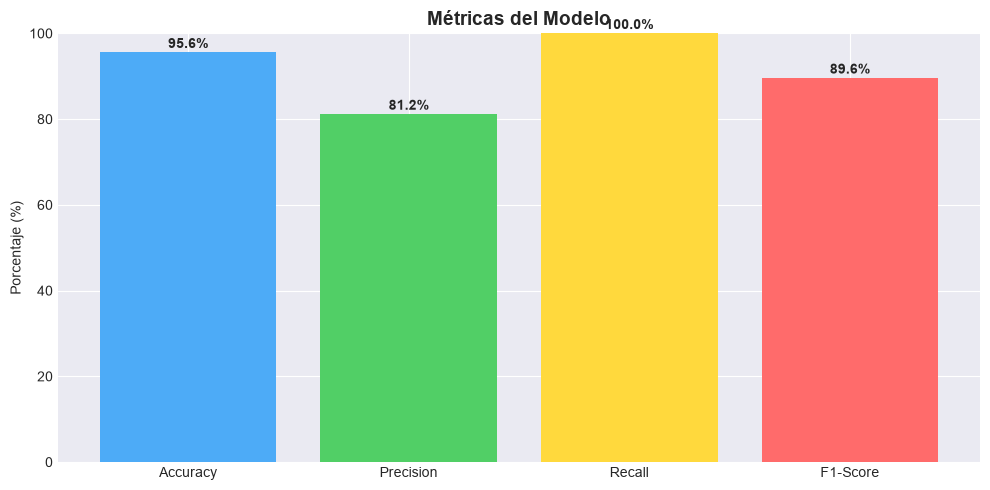

In [8]:
# ============================================================
# ANÁLISIS DEL MODELO
# ============================================================

import json

metrics_path = Path('../modelos/actual/metrics.json')

if metrics_path.exists():
    with open(metrics_path, 'r', encoding='utf-8') as f:
        metricas = json.load(f)
    
    print("=" * 60)
    print("🧠 MÉTRICAS DEL MODELO")
    print("=" * 60)
    
    for key, value in metricas.items():
        if isinstance(value, float) and 0 <= value <= 1:
            print(f"   {key}: {value*100:.2f}%")
        else:
            print(f"   {key}: {value}")
    
    # Visualización
    fig, ax = plt.subplots(figsize=(10, 5))
    
    metricas_viz = {
        'Accuracy': metricas.get('accuracy', 0) * 100,
        'Precision': metricas.get('precision', 0) * 100,
        'Recall': metricas.get('recall', 0) * 100,
        'F1-Score': metricas.get('f1', 0) * 100
    }
    
    bars = ax.bar(metricas_viz.keys(), metricas_viz.values(),
                  color=['#4dabf7', '#51cf66', '#ffd93d', '#ff6b6b'])
    ax.set_title('Métricas del Modelo', fontsize=14, fontweight='bold')
    ax.set_ylabel('Porcentaje (%)')
    ax.set_ylim(0, 100)
    
    for bar, value in zip(bars, metricas_viz.values()):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                f'{value:.1f}%', ha='center', fontweight='bold')
    
    plt.tight_layout()
    plt.show()
else:
    print("⚠️ No hay métricas del modelo")
    print("💡 Ejecuta: python scripts/ejecutar_flujo_completo.py")

## 6. Resumen del Análisis

Conclusiones del análisis exploratorio.

In [9]:
# ============================================================
# RESUMEN DEL ANÁLISIS
# ============================================================

print("=" * 60)
print("📊 RESUMEN DEL ANÁLISIS EXPLORATORIO")
print("=" * 60)
print(f"📅 Fecha: {ahora_peru().strftime('%Y-%m-%d %H:%M:%S')} (Perú)")
print()

for nombre, df in datos.items():
    print(f"📂 {nombre.upper()}:")
    print(f"   ├─ Registros: {len(df):,}")
    print(f"   └─ Columnas: {len(df.columns)}")
    
    if 'id_cliente' in df.columns:
        print(f"      └─ Clientes únicos: {df['id_cliente'].nunique():,}")
    print()

print("=" * 60)
print("✅ Análisis exploratorio completado")
print("=" * 60)

📊 RESUMEN DEL ANÁLISIS EXPLORATORIO
📅 Fecha: 2026-09-10 20:34:59 (Perú)

📂 CLIENTES:
   ├─ Registros: 202
   └─ Columnas: 9
      └─ Clientes únicos: 200

📂 CONSUMO:
   ├─ Registros: 148,196
   └─ Columnas: 4
      └─ Clientes únicos: 362

📂 ALARMAS:
   ├─ Registros: 210
   └─ Columnas: 4
      └─ Clientes únicos: 99

📂 FACTURACION:
   ├─ Registros: 2,424
   └─ Columnas: 7
      └─ Clientes únicos: 200

📂 INSPECCIONES:
   ├─ Registros: 159
   └─ Columnas: 8
      └─ Clientes únicos: 113

📂 HISTORICO:
   ├─ Registros: 362
   └─ Columnas: 9
      └─ Clientes únicos: 362

📂 PUNTAJES:
   ├─ Registros: 362
   └─ Columnas: 6
      └─ Clientes únicos: 362

✅ Análisis exploratorio completado
